# Phase 2 â€” Data Understanding
**Pipeline:** `social_media_analytics`  
**Organization:** Lighthouse PH  
**CRISP-DM Phase:** 2 of 5  

**CRISP-DM Purpose:** Become familiar with the data's structure, variables, quality, and relationships before any transformation.

---

## 2.0 Setup

In [17]:
import sys
from pathlib import Path

# Allow imports from the pipeline root whether running from notebooks/ or pipeline root
PIPELINE_ROOT = Path(".").resolve()
if PIPELINE_ROOT.name == "notebooks":
    PIPELINE_ROOT = PIPELINE_ROOT.parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data_io import load_csv
from src.features import engineer_features, build_targets
from src.config import (
    TARGET_VALUE, TARGET_BINARY, TARGET_LOG,
    PRE_PUB_FEATURES, POST_PUB_FEATURES, EXCLUDE_COLS
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# Load and engineer
df_raw = load_csv()
df     = engineer_features(df_raw)
df     = build_targets(df)

print(f"Dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range    : {df['created_at'].min()} â†’ {df['created_at'].max()}")
print(f"Platforms     : {sorted(df['platform'].unique())}")

Dataset shape : 812 rows x 45 columns
Date range    : 2023-01-05 18:52:00 â†’ 2026-02-26 21:56:00
Platforms     : ['Facebook', 'Instagram', 'LinkedIn', 'TikTok', 'Twitter', 'WhatsApp', 'YouTube']


## 2.1 Data Structure

### 2.1.1 Column inventory

In [18]:
# Column inventory: dtype, missingness, and cardinality
inventory = pd.DataFrame({
    "dtype"      : df.dtypes,
    "n_missing"  : df.isnull().sum(),
    "pct_missing": (df.isnull().mean() * 100).round(1),
    "n_unique"   : df.nunique(),
    "sample_val" : df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else None),
})

# Group by modeling role
pre_cols  = [c for c in PRE_PUB_FEATURES  if c in df.columns]
post_cols = [c for c in POST_PUB_FEATURES if c in df.columns]
excl_cols = [c for c in EXCLUDE_COLS      if c in df.columns]
target_cols = [TARGET_VALUE, TARGET_BINARY, TARGET_LOG, "donation_referrals"]
other_cols  = [c for c in df.columns if c not in pre_cols + post_cols + excl_cols + target_cols]

def print_group(label, cols):
    sub = inventory.loc[[c for c in cols if c in inventory.index]]
    if sub.empty:
        return
    print(f"\n{'â”€'*70}")
    print(f"  {label}")
    print(f"{'â”€'*70}")
    print(sub.to_string())

print_group("TARGETS",                        target_cols)
print_group("PRE-PUBLICATION FEATURES",       pre_cols)
print_group("POST-PUBLICATION FEATURES",      post_cols)
print_group("EXCLUDED (IDs / free text)",     excl_cols)
print_group("OTHER (raw / intermediate)",     other_cols)


â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  TARGETS
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
                                dtype  n_missing  pct_missing  n_unique sample_val
estimated_donation_value_php  float64          0         0.00       523  21,473.25
has_donation                    int64          0         0.00         2          1
log_donation_value            float64          0         0.00       523       9.97
donation_referrals              int64          0         0.00        95         10

â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â

### 2.1.2 Sample rows

In [19]:
display_cols = [
    "platform", "post_type", "media_type", "sentiment_tone",
    "is_boosted", "post_hour", "day_of_week",
    TARGET_VALUE, "donation_referrals", TARGET_BINARY
]
df[display_cols].head(8)

,platform,post_type,media_type,sentiment_tone,is_boosted,post_hour,day_of_week,estimated_donation_value_php,donation_referrals,has_donation
0,WhatsApp,FundraisingAppeal,Text,Grateful,0,18,Thursday,"21,473.25",10,1
1,Instagram,EducationalContent,Photo,Celebratory,0,11,Friday,"4,708.45",2,1
2,LinkedIn,EventPromotion,Text,Urgent,0,10,Sunday,0.00,0,0
3,Instagram,ThankYou,Video,Emotional,0,15,Monday,0.00,0,0
4,TikTok,ThankYou,Reel,Hopeful,1,15,Monday,"8,351.49",2,1
5,Instagram,EventPromotion,Carousel,Emotional,0,13,Thursday,"3,516.65",1,1
6,Facebook,FundraisingAppeal,Video,Celebratory,0,13,Tuesday,"27,029.10",6,1
7,Twitter,FundraisingAppeal,Photo,Urgent,0,18,Tuesday,"55,256.28",14,1


In [ ]:
df['call_to_action_type'].unique()


<StringArray>
['LearnMore', nan, 'DonateNow', 'SignUp', 'ShareStory']
Length: 5, dtype: str

---
## 2.2 Missingness Analysis

In [20]:
# Columns with any missing values
missing = inventory[inventory["n_missing"] > 0][["n_missing", "pct_missing", "dtype"]].sort_values("pct_missing", ascending=False)

print(f"{len(missing)} columns have missing values:\n")
print(missing.to_string())

9 columns have missing values:

                           n_missing  pct_missing    dtype
avg_view_duration_seconds        741        91.30  float64
watch_time_seconds               741        91.30  float64
subscriber_count_at_post         741        91.30  float64
forwards                         719        88.50  float64
boost_budget_php                 685        84.40  float64
campaign_name                    580        71.40      str
video_views                      479        59.00  float64
call_to_action_type              319        39.30      str
hashtags                         148        18.20      str


In [21]:
# Explain platform-specific sparsity
print("video_views â€” non-null count by platform:")
print(df.groupby("platform")["video_views"].count().sort_values(ascending=False).to_string())

print("\nforwards â€” non-null count by platform:")
print(df.groupby("platform")["forwards"].count().sort_values(ascending=False).to_string())

print("\ncall_to_action_type â€” null when has_call_to_action = 0:")
print(df.groupby("has_call_to_action")["call_to_action_type"].apply(lambda x: x.isnull().sum()).rename("nulls").to_string())

video_views â€” non-null count by platform:
platform
TikTok       74
YouTube      71
Facebook     60
Instagram    58
WhatsApp     31
Twitter      28
LinkedIn     11

forwards â€” non-null count by platform:
platform
WhatsApp     93
Instagram     0
Facebook      0
LinkedIn      0
TikTok        0
Twitter       0
YouTube       0

call_to_action_type â€” null when has_call_to_action = 0:
has_call_to_action
0    319
1      0


**Missingness interpretation:**

| Column | Pattern | Handling plan |
|---|---|---|
| `video_views` | Non-null only for Video/Reel content | Post-pub feature; median imputation in preprocessing pipeline |
| `forwards` | Non-null only for WhatsApp posts | Post-pub feature; fill with 0 (absent on other platforms) |
| `engagement_per_follower` | Derived â€” null if `follower_count_at_post` is 0 | Drop rows where denominator is 0; median impute remaining |
| `call_to_action_type` | Null when `has_call_to_action = 0` (structural) | Impute with placeholder category `"None"` |
| `watch_time_seconds`, `avg_view_duration_seconds` | YouTube-specific; **excluded** from models | Already in EXCLUDE_COLS |

> All missingness is **platform-structural** (expected) rather than random data-collection errors. No rows will be dropped.

---
## 2.3 Target Variable Analysis

In [22]:
# Summary statistics for both targets
print("estimated_donation_value_php:")
print(df[TARGET_VALUE].describe().to_string())
print()
print("donation_referrals:")
print(df["donation_referrals"].describe().to_string())

estimated_donation_value_php:
count         812.00
mean       39,772.09
std       124,081.12
min             0.00
25%             0.00
50%         4,556.95
75%        30,072.07
max     2,402,435.96

donation_referrals:
count   812.00
mean     12.80
std      31.26
min       0.00
25%       0.00
50%       2.00
75%      11.00
max     458.00


In [23]:
# Zero-inflation breakdown
n_zero = (df[TARGET_VALUE] == 0).sum()
n_pos  = (df[TARGET_VALUE]  > 0).sum()
pos_rate = n_pos / len(df)

print(f"Zero-value posts    : {n_zero:,}  ({1-pos_rate:.1%}) â†’ Stage 1 negative class")
print(f"Positive-value posts: {n_pos:,}  ({pos_rate:.1%}) â†’ Stage 1 positive class")
print(f"\nClass imbalance ratio: {n_pos/n_zero:.1f}:1 (positive:negative)")
print(f"Majority-class baseline accuracy: {max(n_zero, n_pos)/len(df):.1%}")

Zero-value posts    : 290  (35.7%) â†’ Stage 1 negative class
Positive-value posts: 522  (64.3%) â†’ Stage 1 positive class

Class imbalance ratio: 1.8:1 (positive:negative)
Majority-class baseline accuracy: 64.3%


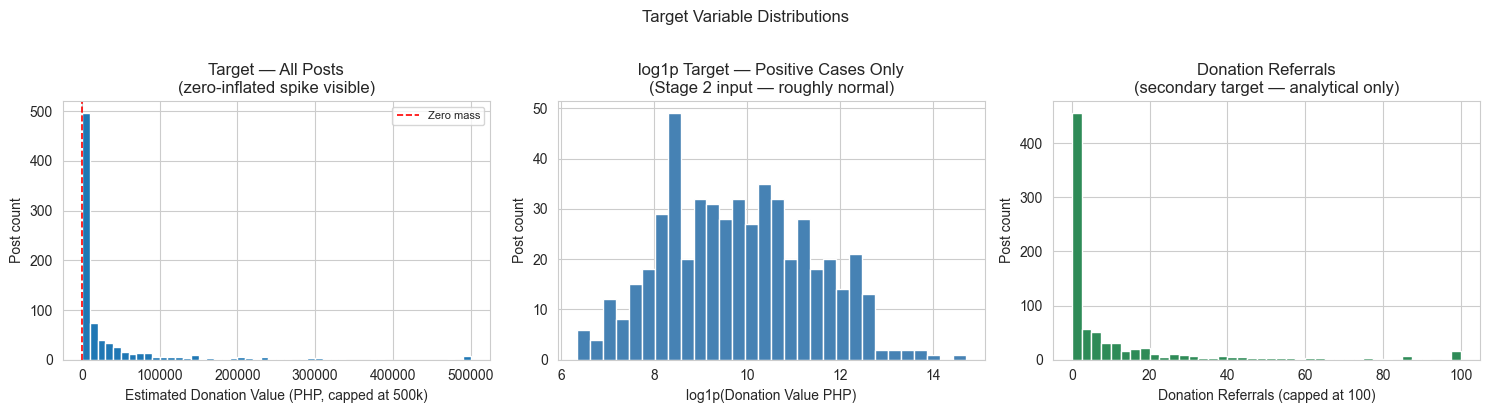

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Raw distribution (all posts)
axes[0].hist(df[TARGET_VALUE].clip(upper=500_000), bins=50, edgecolor="white")
axes[0].set_xlabel("Estimated Donation Value (PHP, capped at 500k)")
axes[0].set_ylabel("Post count")
axes[0].set_title("Target â€” All Posts\n(zero-inflated spike visible)")
axes[0].axvline(0, color="red", linestyle="--", lw=1.2, label="Zero mass")
axes[0].legend(fontsize=8)

# Panel 2: log1p â€” positive cases only (Stage 2 target)
pos_log = df.loc[df[TARGET_VALUE] > 0, TARGET_LOG]
axes[1].hist(pos_log, bins=30, edgecolor="white", color="steelblue")
axes[1].set_xlabel("log1p(Donation Value PHP)")
axes[1].set_ylabel("Post count")
axes[1].set_title("log1p Target â€” Positive Cases Only\n(Stage 2 input â€” roughly normal)")

# Panel 3: donation_referrals (secondary target, analytical only)
axes[2].hist(df["donation_referrals"].clip(upper=100), bins=40, edgecolor="white", color="seagreen")
axes[2].set_xlabel("Donation Referrals (capped at 100)")
axes[2].set_ylabel("Post count")
axes[2].set_title("Donation Referrals\n(secondary target â€” analytical only)")

plt.suptitle("Target Variable Distributions", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**
- The raw target confirms **zero-inflation**: a discrete mass at exactly \$0 followed by a long right tail.
- After `log1p`, the Stage 2 target is approximately bell-shaped â€” validating the log transform choice.
- `donation_referrals` is also zero-inflated and right-skewed; it correlates with but is not identical to `estimated_donation_value_php`.

---
## 2.4 Temporal Scope

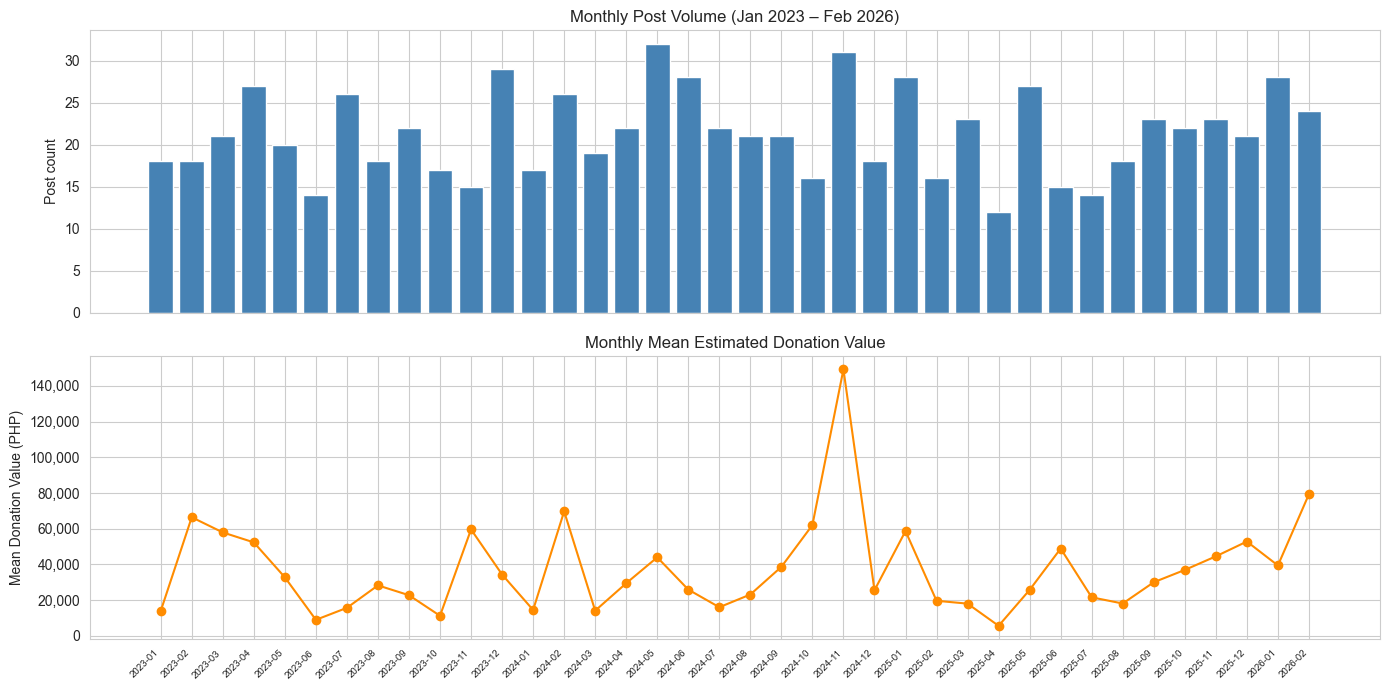

Date range    : 2023-01-05 â†’ 2026-02-26
Total months  : 38
Avg posts/month: 21.4


In [25]:
df["year_month"] = df["created_at"].dt.to_period("M")

monthly = df.groupby("year_month").agg(
    n_posts          = ("post_id", "count"),
    mean_value_php   = (TARGET_VALUE, "mean"),
    pct_has_donation = (TARGET_BINARY, "mean"),
).reset_index()
monthly["year_month_str"] = monthly["year_month"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(monthly["year_month_str"], monthly["n_posts"], color="steelblue", width=0.8)
axes[0].set_ylabel("Post count")
axes[0].set_title("Monthly Post Volume (Jan 2023 â€“ Feb 2026)")

axes[1].plot(monthly["year_month_str"], monthly["mean_value_php"], marker="o", lw=1.5, color="darkorange")
axes[1].set_ylabel("Mean Donation Value (PHP)")
axes[1].set_title("Monthly Mean Estimated Donation Value")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Rotate x-axis
for ax in axes:
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(monthly["year_month_str"], rotation=45, ha="right", fontsize=7)

plt.tight_layout()
plt.show()

print(f"Date range    : {df['created_at'].min().date()} â†’ {df['created_at'].max().date()}")
print(f"Total months  : {monthly.shape[0]}")
print(f"Avg posts/month: {monthly['n_posts'].mean():.1f}")

> **Note on time-series structure:** Although posts are time-ordered, this is **not** a forecasting problem. The unit of analysis is an individual post, and we are explaining/predicting donation value per post. We therefore use a random stratified split (not chronological) in Phase 3 â€” no temporal leakage concern exists since post-publication features are measured contemporaneously with the target.

---
## 2.5 Pre-Publication Feature Distributions

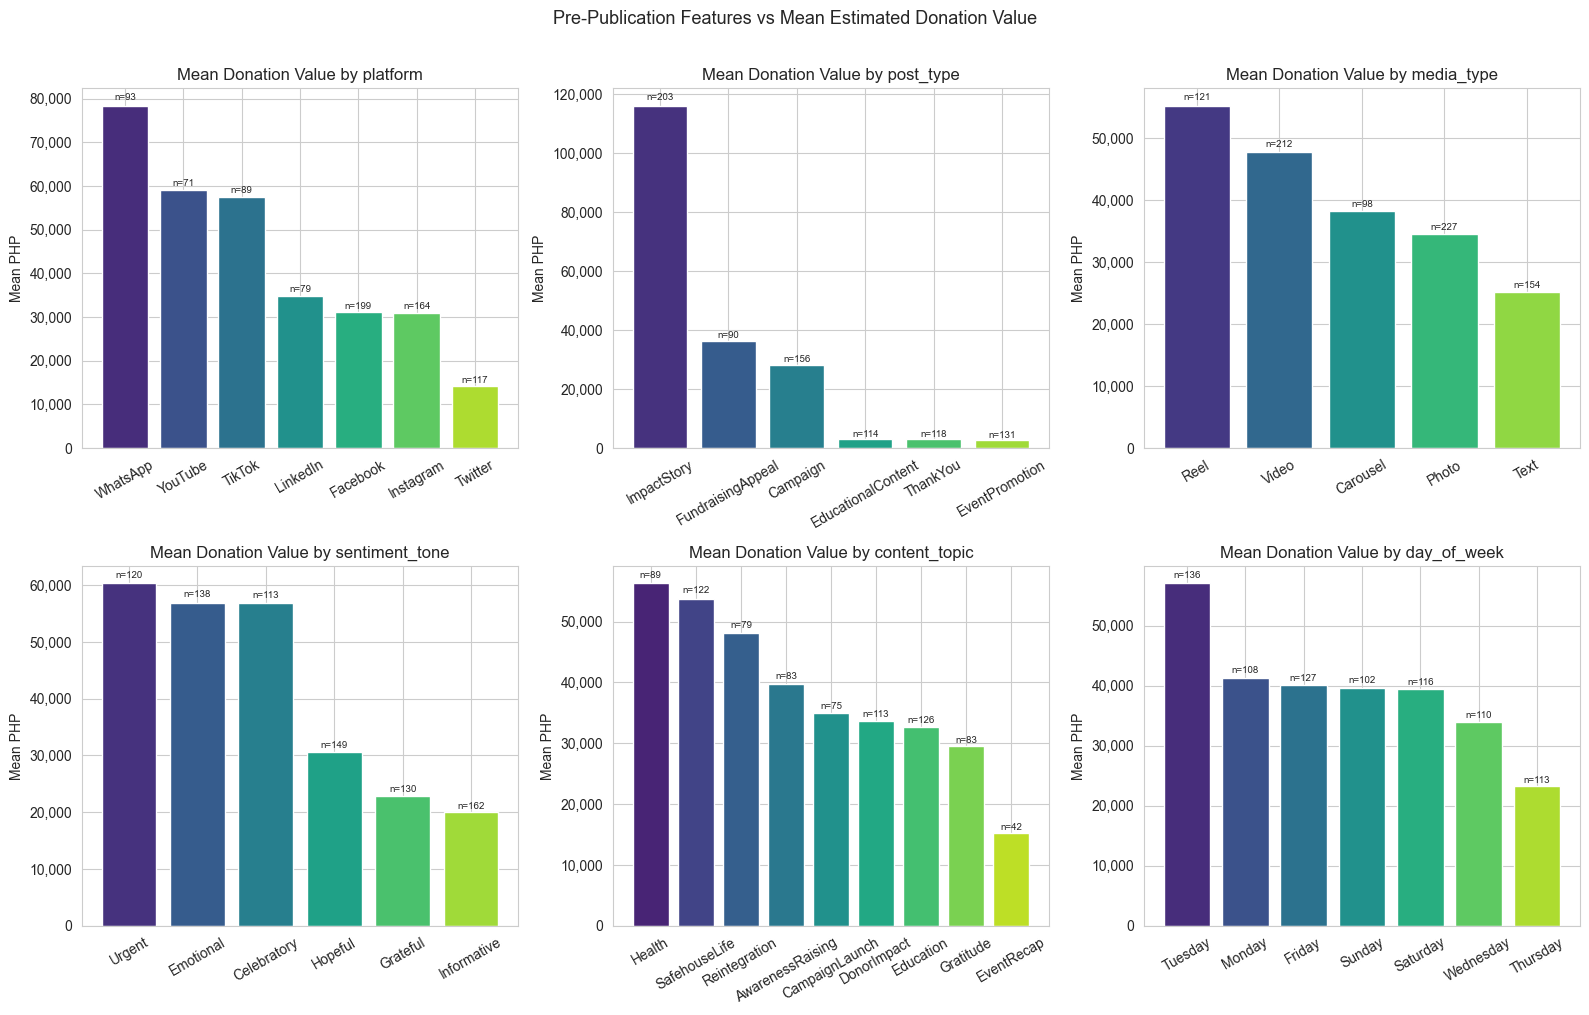

In [26]:
# Categorical pre-pub features vs target
cat_features = ["platform", "post_type", "media_type", "sentiment_tone", "content_topic", "day_of_week"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    summary = (
        df.groupby(feat)[TARGET_VALUE]
        .agg(["mean", "count"])
        .rename(columns={"mean": "mean_value", "count": "n_posts"})
        .sort_values("mean_value", ascending=False)
        .reset_index()
    )
    bars = axes[i].bar(
        summary[feat], summary["mean_value"],
        color=sns.color_palette("viridis", len(summary))
    )
    # Annotate with n
    for bar, n in zip(bars, summary["n_posts"]):
        axes[i].text(
            bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"n={n}", ha="center", va="bottom", fontsize=7
        )
    axes[i].set_title(f"Mean Donation Value by {feat}")
    axes[i].set_ylabel("Mean PHP")
    axes[i].set_xlabel("")
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Pre-Publication Features vs Mean Estimated Donation Value", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

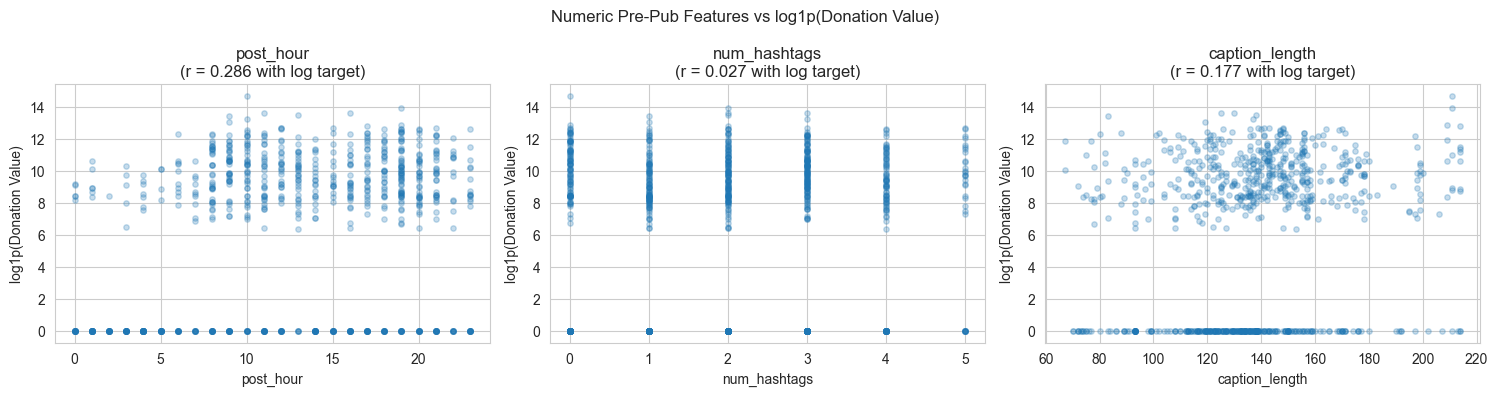

In [27]:
# Numeric pre-pub features
num_pre = ["post_hour", "num_hashtags", "caption_length"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(num_pre):
    axes[i].scatter(
        df[feat].clip(upper=df[feat].quantile(0.99)),
        df[TARGET_LOG],
        alpha=0.25, s=15
    )
    corr = df[feat].corr(df[TARGET_LOG])
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("log1p(Donation Value)")
    axes[i].set_title(f"{feat}\n(r = {corr:.3f} with log target)")

plt.suptitle("Numeric Pre-Pub Features vs log1p(Donation Value)", fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
# Engineered binary features
binary_features = ["is_boosted", "has_call_to_action", "features_resident_story",
                   "is_peak_hour", "is_peak_day", "has_video_content", "is_impact_or_fundraising"]
binary_features = [f for f in binary_features if f in df.columns]

rows = []
for f in binary_features:
    g = df.groupby(f)[TARGET_VALUE].agg(["mean", "count"]).rename(columns={"mean": "mean_php", "count": "n"})
    rows.append({
        "feature"        : f,
        "mean_php (0)"   : g.loc[0, "mean_php"] if 0 in g.index else None,
        "n (0)"          : g.loc[0, "n"]        if 0 in g.index else None,
        "mean_php (1)"   : g.loc[1, "mean_php"] if 1 in g.index else None,
        "n (1)"          : g.loc[1, "n"]        if 1 in g.index else None,
        "lift (1 vs 0)"  : (g.loc[1, "mean_php"] / g.loc[0, "mean_php"])
                           if (0 in g.index and 1 in g.index and g.loc[0, "mean_php"] > 0) else None,
    })
binary_df = pd.DataFrame(rows).set_index("feature")
binary_df

,mean_php (0),n (0),mean_php (1),n (1),lift (1 vs 0)
feature,,,,,
is_boosted,"34,057.46",685,"70,595.14",127,2.07
has_call_to_action,"45,173.36",319,"36,277.16",493,0.80
features_resident_story,"16,009.99",647,"132,948.35",165,8.30
is_peak_hour,"23,839.41",430,"57,706.79",382,2.42
is_peak_day,"39,752.32",345,"39,786.70",467,1.00
has_video_content,"12,328.73",360,"61,629.64",452,5.00
is_impact_or_fundraising,"40,222.88",722,"36,155.81",90,0.90


---
## 2.6 Post-Publication Feature Analysis

> **Reminder:** Post-publication features (shares, likes, reach, etc.) are observed *after* a post goes live. They are included in the **explanatory model** to understand what post performance characteristics mediate donation outcomes. They are **excluded from the recommendation model** and cannot be used to plan posts before publishing.

In [29]:
# Correlation of post-pub features with both targets (log-scale)
post_pub_present = [c for c in POST_PUB_FEATURES if c in df.columns]

corr_df = df[post_pub_present + [TARGET_LOG, "donation_referrals"]].corr()
corr_targets = corr_df.loc[post_pub_present, [TARGET_LOG, "donation_referrals"]].rename(
    columns={TARGET_LOG: "log_donation_value", "donation_referrals": "donation_referrals"}
).sort_values("log_donation_value", ascending=False)

print("Pearson correlation (post-pub features â†’ targets):")
print(corr_targets.round(3).to_string())

Pearson correlation (post-pub features â†’ targets):
                 log_donation_value  donation_referrals
video_views                    0.51                0.43
shares                         0.51                0.73
engagement_rate                0.49                0.27
reach                          0.49                0.48
impressions                    0.49                0.48
saves                          0.48                0.50
likes                          0.46                0.55
profile_visits                 0.46                0.47
forwards                       0.43                0.95
click_throughs                 0.43                0.39


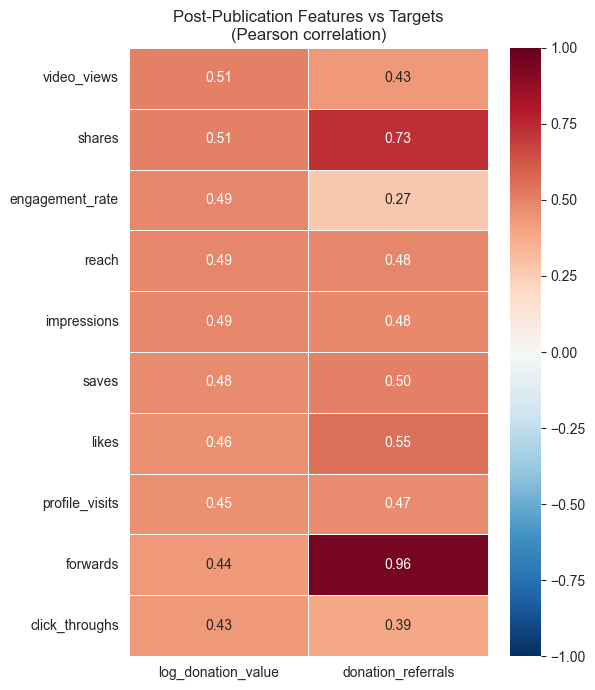

In [30]:
# Heatmap
fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(
    corr_targets,
    annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title("Post-Publication Features vs Targets\n(Pearson correlation)")
plt.tight_layout()
plt.show()

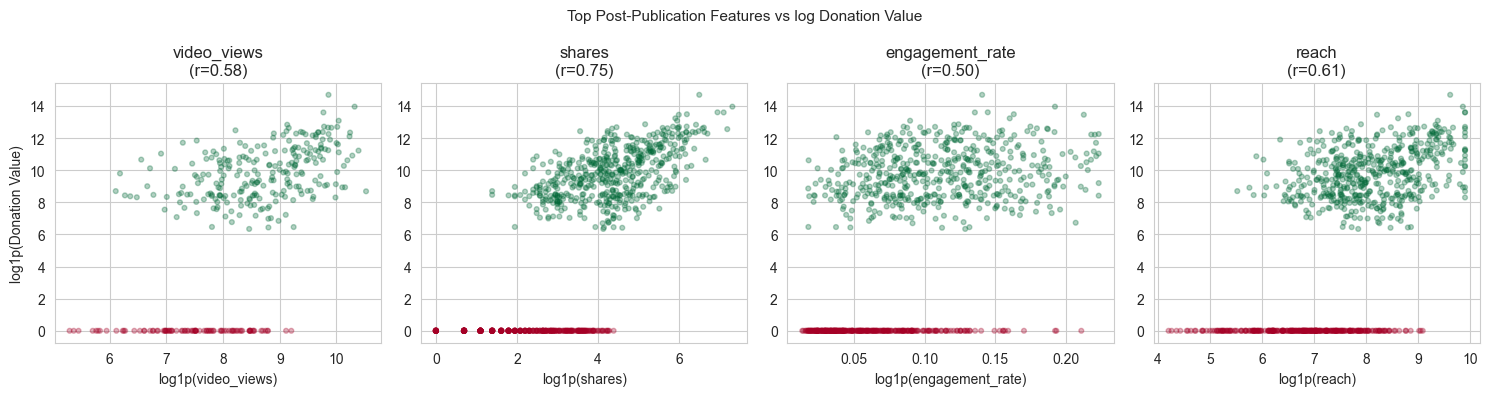

In [31]:
# Pairplot of highest-correlated post-pub features
top_post_pub = corr_targets["log_donation_value"].abs().nlargest(4).index.tolist()
plot_cols = top_post_pub + [TARGET_LOG, TARGET_BINARY]
plot_df = df[plot_cols].copy()

fig, axes = plt.subplots(1, len(top_post_pub), figsize=(15, 4))
for i, feat in enumerate(top_post_pub):
    axes[i].scatter(
        np.log1p(df[feat].clip(lower=0)),
        df[TARGET_LOG],
        c=df[TARGET_BINARY], cmap="RdYlGn",
        alpha=0.3, s=12
    )
    corr_val = np.log1p(df[feat].clip(lower=0)).corr(df[TARGET_LOG])
    axes[i].set_xlabel(f"log1p({feat})")
    axes[i].set_ylabel("log1p(Donation Value)" if i == 0 else "")
    axes[i].set_title(f"{feat}\n(r={corr_val:.2f})")

plt.suptitle("Top Post-Publication Features vs log Donation Value", fontsize=11)
plt.tight_layout()
plt.show()

---
## 2.7 Within-Platform Analysis

Different platforms have structurally different engagement metrics and follower bases. The table below shows how average donation value and post-type mix vary by platform.

In [38]:
platform_summary = df.groupby("platform").agg(
    n_posts           = ("post_id",          "count"),
    pct_has_donation  = (TARGET_BINARY,       "mean"),
    mean_value_php    = (TARGET_VALUE,        "mean"),
    median_value_php  = (TARGET_VALUE,        "median"),
    pct_boosted       = ("is_boosted",        "mean"),
    mean_engagement   = ("engagement_rate",   "mean"),
).sort_values("mean_value_php", ascending=False)

platform_summary["pct_has_donation"] = platform_summary["pct_has_donation"].map("{:.1%}".format)
platform_summary["pct_boosted"]      = platform_summary["pct_boosted"].map("{:.1%}".format)
platform_summary["mean_engagement"]  = platform_summary["mean_engagement"].map("{:.1%}".format)
for col in ["mean_value_php", "median_value_php"]:
    platform_summary[col] = platform_summary[col].map(lambda x: f"{x:,.0f}")
print(platform_summary.to_string())

           n_posts pct_has_donation mean_value_php median_value_php pct_boosted mean_engagement
platform                                                                                       
WhatsApp        93            64.5%         78,438            8,737       12.9%            9.2%
YouTube         71            77.5%         59,061            9,181       19.7%            9.9%
TikTok          89            75.3%         57,425           12,476       22.5%            9.9%
LinkedIn        79            40.5%         34,921                0       17.7%            9.8%
Facebook       199            61.3%         31,086            3,201       15.6%            9.4%
Instagram      164            68.3%         30,989            4,323       12.2%           10.6%
Twitter        117            63.2%         14,264            3,274       13.7%           10.4%


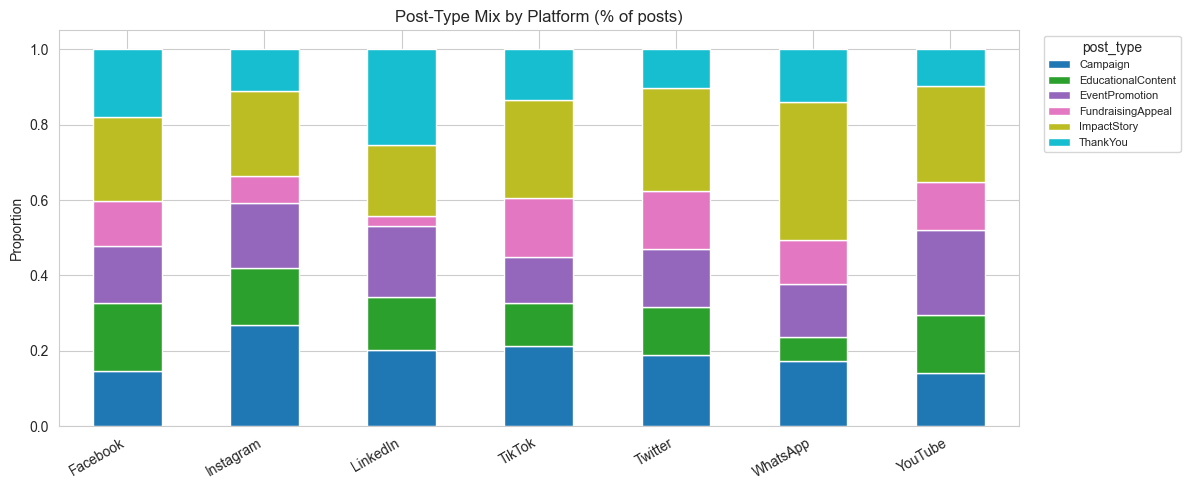

In [39]:
# Post-type mix by platform (normalized)
pt_mix = (
    df.groupby(["platform", "post_type"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)

pt_mix.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab10")
plt.title("Post-Type Mix by Platform (% of posts)")
plt.ylabel("Proportion")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.legend(title="post_type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
## 2.8 Data Quality Issues Register

In [40]:
quality_issues = [
    {
        "column"         : "video_views",
        "issue"          : "Platform-specific sparsity",
        "description"    : "Non-null only for Video/Reel posts. NaN on Text/Photo/Carousel.",
        "severity"       : "Low",
        "handling"       : "Median imputation in preprocessing pipeline",
    },
    {
        "column"         : "forwards",
        "issue"          : "Platform-specific sparsity",
        "description"    : "Non-null only for WhatsApp posts. Structural absence elsewhere.",
        "severity"       : "Low",
        "handling"       : "Fill NaN with 0 before imputation",
    },
    {
        "column"         : "call_to_action_type",
        "issue"          : "Structural missingness",
        "description"    : "Null when has_call_to_action = 0. Not missing-at-random.",
        "severity"       : "Low",
        "handling"       : "Impute with category 'None' (most-frequent in preprocessing)",
    },
    {
        "column"         : "engagement_per_follower",
        "issue"          : "Division by zero",
        "description"    : "NaN when follower_count_at_post = 0 (very rare).",
        "severity"       : "Low",
        "handling"       : "Replace 0 denominator with NaN before dividing; median impute",
    },
    {
        "column"         : "is_boosted, has_call_to_action, features_resident_story",
        "issue"          : "Boolean stored as string",
        "description"    : "CSV stores True/False as string literals.",
        "severity"       : "Low",
        "handling"       : "Coerced to int (0/1) in engineer_features()",
    },
    {
        "column"         : "estimated_donation_value_php",
        "issue"          : "Zero inflation",
        "description"    : f"35.7% of posts have $0 value. Standard regression would be biased.",
        "severity"       : "High (architectural)",
        "handling"       : "Two-stage model: Stage 1 classifier + Stage 2 log regressor on positives",
    },
    {
        "column"         : "estimated_donation_value_php",
        "issue"          : "Right-skewed heavy tail",
        "description"    : "Max value is 2.4M PHP; p75 is ~30k. Strong skew in positive cases.",
        "severity"       : "Medium",
        "handling"       : "log1p transform on Stage 2 target; evaluate in PHP via expm1",
    },
]

pd.DataFrame(quality_issues)

,column,issue,description,severity,handling
0,video_views,Platform-specific sparsity,Non-null only for Video/Reel posts. NaN on Tex...,Low,Median imputation in preprocessing pipeline
1,forwards,Platform-specific sparsity,Non-null only for WhatsApp posts. Structural a...,Low,Fill NaN with 0 before imputation
2,call_to_action_type,Structural missingness,Null when has_call_to_action = 0. Not missing-...,Low,Impute with category 'None' (most-frequent in ...
3,engagement_per_follower,Division by zero,NaN when follower_count_at_post = 0 (very rare).,Low,Replace 0 denominator with NaN before dividing...
4,"is_boosted, has_call_to_action, features_resid...",Boolean stored as string,CSV stores True/False as string literals.,Low,Coerced to int (0/1) in engineer_features()
5,estimated_donation_value_php,Zero inflation,35.7% of posts have $0 value. Standard regress...,High (architectural),Two-stage model: Stage 1 classifier + Stage 2 ...
6,estimated_donation_value_php,Right-skewed heavy tail,Max value is 2.4M PHP; p75 is ~30k. Strong ske...,Medium,log1p transform on Stage 2 target; evaluate in...


---
## 2.9 Key Findings Summary

| Finding | Implication for modeling |
|---|---|
| **ImpactStory posts average 3â€“4Ã— the donation value of other types** | `post_type` will be a strong predictor in both models |
| **WhatsApp and YouTube lead in mean value; Twitter/X lags** | `platform` should be a first-order feature |
| **Boosted posts average ~2Ã— unboosted** | `is_boosted` is a strong pre-pub signal â€” but confounded (org may boost already-good content) |
| **Shares and reach are the strongest post-pub correlates of donation value** | Explanatory model will identify these; cannot be used pre-publication |
| **35.7% zero-value posts confirm the two-stage model design** | Stage 1 classifier needed; majority-class baseline is 64.3% |
| **Post distribution is roughly uniform across months; no clear seasonality** | Random stratified split is safe; no temporal CV required |
| **Platform-specific column sparsity is structural, not errors** | No rows dropped; handle in preprocessing imputation |

---
## 2.10 Phase 2 Sign-Off Checklist

- [x] Data shape and structure documented (812 rows Ã— 39+ columns)
- [x] Missingness report complete â€” all patterns explained
- [x] Target distribution analyzed â€” zero-inflation confirmed at 35.7%
- [x] Temporal scope documented (Jan 2023 â€“ Feb 2026, ~37 months)
- [x] Pre-publication features explored vs target â€” platform and post_type show clear signal
- [x] Post-publication features explored â€” shares and reach highest correlated
- [x] Within-platform breakdown complete
- [x] Data quality issues register written â€” no rows dropped

**Phase 2 status: COMPLETE. Proceed to Phase 3 â€” Data Preparation.**